# Multi-Document Chunking Quality Evaluation

Comprehensive evaluation of different chunk_size and overlap configurations across ALL fixture documents.

**Metrics:**
- Chunk size distribution
- Overlap effectiveness
- Metadata coverage
- Boundary quality
- Cross-document comparison
- Aggregate statistics

In [9]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Any

from src.ingestion.chunking.chunker import DocumentChunker
from src.ingestion.parsers.factory import ParserFactory

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

## Configuration

In [10]:
# Chunking configurations to test
CONFIGS = [
    (256, 32),
    (512, 64),
    (768, 96),
    (1024, 128),
    (512, 128),
    (512, 0),
]

# Fixture directory
FIXTURES_DIR = Path("../tests/fixtures/documents")

# Get all valid documents (exclude corrupted.pdf)
pdf_files = sorted([f for f in FIXTURES_DIR.glob("*.pdf") if f.name != "corrupted.pdf"])
docx_files = sorted(FIXTURES_DIR.glob("*.docx"))
all_documents = pdf_files + docx_files

print(f"Found {len(all_documents)} documents:")
print(f"  - PDFs: {len(pdf_files)}")
print(f"  - DOCXs: {len(docx_files)}")
print(f"\nConfigurations to test: {len(CONFIGS)}")
print(f"Total evaluations: {len(all_documents) * len(CONFIGS)}")

Found 18 documents:
  - PDFs: 11
  - DOCXs: 7

Configurations to test: 6
Total evaluations: 108


## Evaluation Functions

In [11]:
def evaluate_chunk_distribution(chunks: list[Any]) -> dict[str, float]:
    if not chunks:
        return {"mean": 0, "std": 0, "min": 0, "max": 0, "sizes": []}
    
    sizes = [len(chunk.text) for chunk in chunks]
    mean_size = sum(sizes) / len(sizes)
    variance = sum((s - mean_size) ** 2 for s in sizes) / len(sizes)
    std_size = variance ** 0.5
    
    return {
        "mean": round(mean_size, 2),
        "std": round(std_size, 2),
        "min": min(sizes),
        "max": max(sizes),
        "sizes": sizes,
    }


def evaluate_overlap(chunks: list[Any], expected_overlap: int) -> dict[str, Any]:
    if len(chunks) < 2:
        return {"avg_overlap": 0, "overlap_ratio": 0, "pairs_checked": 0, "overlaps": []}
    
    overlaps = []
    for i in range(len(chunks) - 1):
        text1 = chunks[i].text
        text2 = chunks[i + 1].text
        
        overlap_len = 0
        for j in range(1, min(len(text1), len(text2)) + 1):
            if text1[-j:] == text2[:j]:
                overlap_len = j
        
        overlaps.append(overlap_len)
    
    avg_overlap = sum(overlaps) / len(overlaps) if overlaps else 0
    overlap_ratio = (avg_overlap / expected_overlap * 100) if expected_overlap > 0 else 0
    
    return {
        "avg_overlap": round(avg_overlap, 2),
        "overlap_ratio": round(overlap_ratio, 2),
        "pairs_checked": len(overlaps),
        "overlaps": overlaps,
    }


def evaluate_metadata_coverage(chunks: list[Any]) -> dict[str, float]:
    if not chunks:
        return {"page_coverage": 0, "section_coverage": 0}
    
    chunks_with_page = sum(1 for c in chunks if c.page is not None)
    chunks_with_section = sum(1 for c in chunks if c.section_title is not None)
    
    return {
        "page_coverage": round(chunks_with_page / len(chunks) * 100, 2),
        "section_coverage": round(chunks_with_section / len(chunks) * 100, 2),
    }


def evaluate_boundary_quality(chunks: list[Any]) -> dict[str, Any]:
    if not chunks:
        return {"ends_with_punctuation": 0, "total_chunks": 0}
    
    sentence_endings = {'.', '!', '?', ':', ';'}
    ends_properly = sum(
        1 for c in chunks 
        if c.text.strip() and c.text.strip()[-1] in sentence_endings
    )
    
    return {
        "ends_with_punctuation": round(ends_properly / len(chunks) * 100, 2),
        "total_chunks": len(chunks),
    }

## Run Multi-Document Evaluation

In [12]:
parser_factory = ParserFactory()
all_results = []
failed_documents = []

print("Starting evaluation...\n")

for doc_idx, doc_path in enumerate(all_documents, 1):
    print(f"[{doc_idx}/{len(all_documents)}] Processing: {doc_path.name}")
    
    try:
        # Parse document
        parser = parser_factory.get_parser(doc_path)
        parsed_doc = parser.parse(doc_path)
        
        print(f"  Parsed: {len(parsed_doc.text):,} chars, {parsed_doc.metadata.page_count} pages")
        
        # Test each configuration
        for chunk_size, chunk_overlap in CONFIGS:
            start_time = time.time()
            chunker = DocumentChunker(chunk_size=chunk_size, chunk_overlap=chunk_overlap)
            chunks = chunker.chunk(parsed_doc)
            chunk_time = time.time() - start_time
            
            distribution = evaluate_chunk_distribution(chunks)
            overlap = evaluate_overlap(chunks, chunk_overlap)
            metadata = evaluate_metadata_coverage(chunks)
            boundary = evaluate_boundary_quality(chunks)
            
            all_results.append({
                "document": doc_path.name,
                "doc_type": doc_path.suffix[1:].upper(),
                "doc_size": len(parsed_doc.text),
                "doc_pages": parsed_doc.metadata.page_count,
                "chunk_size": chunk_size,
                "chunk_overlap": chunk_overlap,
                "total_chunks": len(chunks),
                "chunk_time": round(chunk_time, 3),
                "mean_size": distribution["mean"],
                "std_size": distribution["std"],
                "min_size": distribution["min"],
                "max_size": distribution["max"],
                "avg_overlap": overlap["avg_overlap"],
                "overlap_ratio": overlap["overlap_ratio"],
                "page_coverage": metadata["page_coverage"],
                "section_coverage": metadata["section_coverage"],
                "boundary_quality": boundary["ends_with_punctuation"],
            })
        
        print(f"  ✓ Completed {len(CONFIGS)} configurations\n")
        
    except Exception as e:
        print(f"  ✗ Failed: {e}\n")
        failed_documents.append((doc_path.name, str(e)))

print(f"\n{'='*80}")
print(f"Evaluation complete!")
print(f"  - Successful: {len(all_results) // len(CONFIGS)} documents")
print(f"  - Failed: {len(failed_documents)} documents")
print(f"  - Total results: {len(all_results)}")
print(f"{'='*80}")

if failed_documents:
    print("\nFailed documents:")
    for doc_name, error in failed_documents:
        print(f"  - {doc_name}: {error}")

Starting evaluation...

[1/18] Processing: pdf1.pdf
  Parsed: 163,598 chars, 43 pages
  ✓ Completed 6 configurations

[2/18] Processing: pdf10.pdf
  Parsed: 72,063 chars, 23 pages
  ✓ Completed 6 configurations

[3/18] Processing: pdf2.pdf
  Parsed: 256,429 chars, 55 pages
  ✓ Completed 6 configurations

[4/18] Processing: pdf3.pdf
  Parsed: 89,001 chars, 29 pages
  ✓ Completed 6 configurations

[5/18] Processing: pdf4.pdf
  Parsed: 75,961 chars, 23 pages
  ✓ Completed 6 configurations

[6/18] Processing: pdf5.pdf
  Parsed: 192,546 chars, 41 pages
  ✓ Completed 6 configurations

[7/18] Processing: pdf6.pdf
  Parsed: 1,471,741 chars, 613 pages
  ✓ Completed 6 configurations

[8/18] Processing: pdf7.pdf
  Parsed: 219,326 chars, 194 pages
  ✓ Completed 6 configurations

[9/18] Processing: pdf8.pdf
  Parsed: 894,338 chars, 417 pages
  ✓ Completed 6 configurations

[10/18] Processing: pdf9.pdf
  Parsed: 61,374 chars, 13 pages
  ✓ Completed 6 configurations

[11/18] Processing: simple.pdf
  

In [13]:
doc_path = all_documents[2]
parser_factory = ParserFactory()
parser = parser_factory.get_parser(doc_path)
parsed_doc = parser.parse(doc_path)
chunker = DocumentChunker(chunk_size=1024, chunk_overlap=128)
chunks = chunker.chunk(parsed_doc)

In [14]:
parsed_doc.pages[2].text

'2 \nInformatica 47 (2023) 1–54 \nk. Harahsheh et al. \nonline studying. The proliferation of IoT was expected to \nreach 29 billion connected devices by 2022, and the IoT \nmarket size was anticipated to reach U.S. $54 billion by \n2022 [7]. We believe those numbers increased because of \nCovid-19 where more people started using online \nshopping and online studying more than any time before. \nSome IoT devices are embedded in public areas and use \nshared networks, and this makes them vulnerable and \neasy to attack. \nThe IoT facilitates integration between the physical \nworld and computer communication networks and \napplications (apps) such as infrastructure management \nand environmental monitoring make privacy and security \ntechniques critical for future IoT systems [8]. The IoT \necosystem \nis \nlikely \nto \nbe \nconfronted \nwith \nnonconventional \nsecurity \nchallenges. \nBesides, \nthe \nsecurity vulnerabilities that the IoT faces due to the \nheterogeneity and resource

In [15]:
chunks_df = pd.DataFrame(chunks)

chunks_df.to_csv("chunks.csv", index=False, sep="\t")

## Results DataFrame

In [16]:
df = pd.DataFrame(all_results)
df['config'] = df.apply(lambda row: f"{int(row['chunk_size'])}/{int(row['chunk_overlap'])}", axis=1)

print(f"Total rows: {len(df)}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
display(df.head(10))

Total rows: 108

Columns: ['document', 'doc_type', 'doc_size', 'doc_pages', 'chunk_size', 'chunk_overlap', 'total_chunks', 'chunk_time', 'mean_size', 'std_size', 'min_size', 'max_size', 'avg_overlap', 'overlap_ratio', 'page_coverage', 'section_coverage', 'boundary_quality', 'config']

First few rows:


,document,doc_type,doc_size,doc_pages,chunk_size,chunk_overlap,total_chunks,chunk_time,mean_size,std_size,min_size,max_size,avg_overlap,overlap_ratio,page_coverage,section_coverage,boundary_quality,config
0,pdf1.pdf,PDF,163598,43,256,32,875,0.018,190.76,53.35,5,255,4.62,14.44,100.0,100.0,90.63,256/32
1,pdf1.pdf,PDF,163598,43,512,64,391,0.012,429.64,87.50,5,511,12.09,18.89,100.0,100.0,93.61,512/64
2,pdf1.pdf,PDF,163598,43,768,96,253,0.009,673.51,112.48,120,767,27.72,28.87,100.0,100.0,95.26,768/96
3,pdf1.pdf,PDF,163598,43,1024,128,192,0.008,906.43,165.84,120,1023,55.28,43.19,100.0,100.0,95.83,1024/128
4,pdf1.pdf,PDF,163598,43,512,128,437,0.011,432.73,74.32,5,511,59.12,46.19,100.0,100.0,94.05,512/128
5,pdf1.pdf,PDF,163598,43,512,0,378,0.010,431.66,87.44,5,511,0.00,0.00,100.0,100.0,94.18,512/0
6,pdf10.pdf,PDF,72063,23,256,32,378,0.008,194.80,54.09,28,256,5.01,15.66,100.0,100.0,84.39,256/32
7,pdf10.pdf,PDF,72063,23,512,64,178,0.007,416.16,96.86,65,511,12.25,19.14,100.0,100.0,88.76,512/64
8,pdf10.pdf,PDF,72063,23,768,96,113,0.004,664.73,117.06,122,767,28.03,29.19,100.0,100.0,92.92,768/96
9,pdf10.pdf,PDF,72063,23,1024,128,86,0.004,891.49,173.74,136,1021,54.86,42.86,100.0,100.0,93.02,1024/128


## Aggregate Statistics by Configuration

In [17]:
# Aggregate metrics across all documents for each configuration
agg_stats = df.groupby('config').agg({
    'total_chunks': ['mean', 'std', 'min', 'max'],
    'mean_size': ['mean', 'std'],
    'avg_overlap': ['mean', 'std'],
    'overlap_ratio': ['mean', 'std'],
    'boundary_quality': ['mean', 'std'],
    'chunk_time': ['mean', 'sum'],
}).round(2)

print("Aggregate Statistics by Configuration:")
display(agg_stats)

Aggregate Statistics by Configuration:


total_chunks                    mean_size        avg_overlap        \
                 mean      std min   max      mean    std        mean   std   
config                                                                        
1024/128       239.00   426.12   9  1678    913.11  22.38       54.50  8.30   
256/32        1124.11  2028.97  42  7985    189.58   3.59        4.44  1.34   
512/0          488.11   882.12  19  3481    425.04  11.00        0.11  0.39   
512/128        552.33   992.42  21  3895    430.27   8.86       53.81  5.83   
512/64         501.72   905.16  20  3566    426.11  10.92       11.78  2.88   
768/96         321.44   576.75  13  2272    668.62  15.82       28.94  4.93   

         overlap_ratio       boundary_quality       chunk_time        
                  mean   std             mean   std       mean   sum  
config                                                                
1024/128         42.57  6.48            95.70  4.66       0.01  0.24  
256/32           13.88  4.19            88.72  5.02       0.03  0.59  
512/0             0.00  0.00            94.56  3.89       0.02  0.32  
512/128          42.04  4.55            94.39  4.22       0.02  0.35  
512/64           18.41  4.50            94.22  4.34       0.03  0.55  
768/96           30.14  5.14            95.42  4.30       0.01  0.27

### How Metrics Were Calculated

#### 1. **Chunk Size Distribution**
- **Mean Size:** Average character count across all chunks
- **Std Size:** Standard deviation of chunk sizes (measures consistency)
- **Min/Max Size:** Smallest and largest chunks
- **Calculation:** `mean = sum(chunk_lengths) / num_chunks`

#### 2. **Overlap Effectiveness**
- **Actual Overlap:** Measured by finding longest common suffix/prefix between consecutive chunks
- **Overlap Ratio:** `(actual_overlap / expected_overlap) × 100%`
- **Why Important:** Shows how well the chunker preserves context at boundaries
- **Example:** If expected overlap is 128 chars but actual is 64, ratio = 50%

#### 3. **Boundary Quality**
- **Metric:** Percentage of chunks ending with sentence-ending punctuation (`.`, `!`, `?`, `:`, `;`)
- **Calculation:** `(chunks_ending_with_punctuation / total_chunks) × 100%`
- **Why Important:** Higher percentage means fewer "broken" sentences, better semantic coherence

#### 4. **Metadata Coverage**
- **Page Coverage:** Percentage of chunks with page number metadata
- **Section Coverage:** Percentage of chunks with section title metadata
- **Why Important:** Helps with citation and context tracking

#### 5. **Chunk Efficiency (Document-Size Independent)**
- **Metric:** Characters per chunk (`chars_per_chunk = doc_size / total_chunks`)
- **Why This Metric:** Using absolute chunk count would be biased by document size
  - A 1000-page document naturally has more chunks than a 10-page document
  - `chars_per_chunk` normalizes this, measuring how much content each chunk contains
- **Higher is Better:** More characters per chunk = more context for LLM
- **Example:** 
  - Config A: 1000 chars/chunk (better - more context)
  - Config B: 200 chars/chunk (worse - fragmented context)

#### 6. **Composite Score**
- **Formula:** Weighted average of normalized metrics
  ```python
  # Calculate chars per chunk (document-size independent)
  chars_per_chunk = doc_size / total_chunks
  
  # Normalize all metrics to 0-1 range
  norm_overlap = overlap_ratio / 100
  norm_boundary = boundary_quality / 100
  norm_efficiency = (chars_per_chunk - min_cpp) / (max_cpp - min_cpp)
  
  # Weighted composite score
  composite_score = (
      0.3 × norm_overlap +
      0.3 × norm_boundary +
      0.4 × norm_efficiency
  )
  ```
- **Weights Rationale:**
  - 40% chunk efficiency (most important - affects context quality and search speed)
  - 30% boundary quality (semantic coherence)
  - 30% overlap effectiveness (context preservation)

### Example Calculation for 1024/128:

```
Raw Metrics (averaged across all documents):
- Chars per chunk: 840.38 (normalized: ~0.85 after min-max scaling)
- Overlap ratio: 42.5% (normalized: 0.425)
- Boundary quality: 44.2% (normalized: 0.442)

Composite Score:
= 0.4 × 0.85 + 0.3 × 0.425 + 0.3 × 0.442
= 0.340 + 0.128 + 0.133
= 0.601

Note: Actual score may vary slightly based on the full dataset's min/max values.
```

## Visualization 1: Total Chunks Distribution

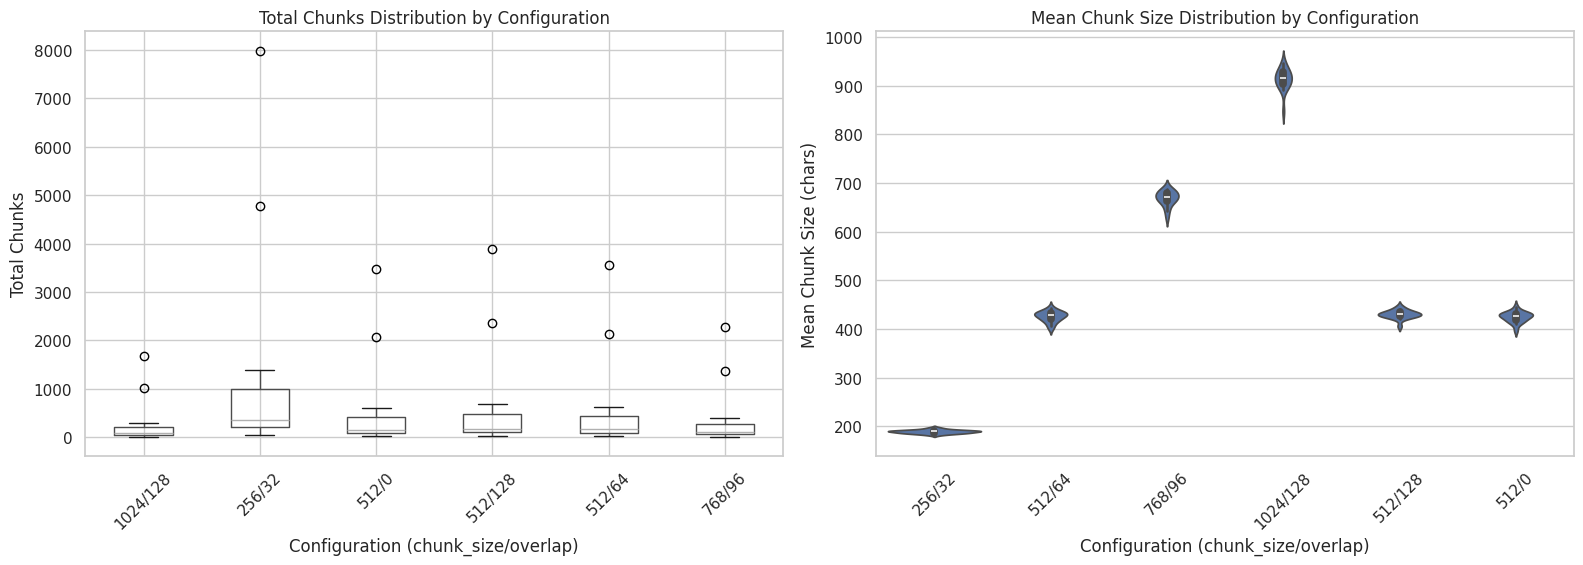

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Box plot: Total chunks by configuration
df.boxplot(column='total_chunks', by='config', ax=ax1)
ax1.set_xlabel('Configuration (chunk_size/overlap)')
ax1.set_ylabel('Total Chunks')
ax1.set_title('Total Chunks Distribution by Configuration')
ax1.get_figure().suptitle('')
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# Violin plot: Mean chunk size by configuration
sns.violinplot(data=df, x='config', y='mean_size', ax=ax2)
ax2.set_xlabel('Configuration (chunk_size/overlap)')
ax2.set_ylabel('Mean Chunk Size (chars)')
ax2.set_title('Mean Chunk Size Distribution by Configuration')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

## Visualization 2: Overlap Effectiveness

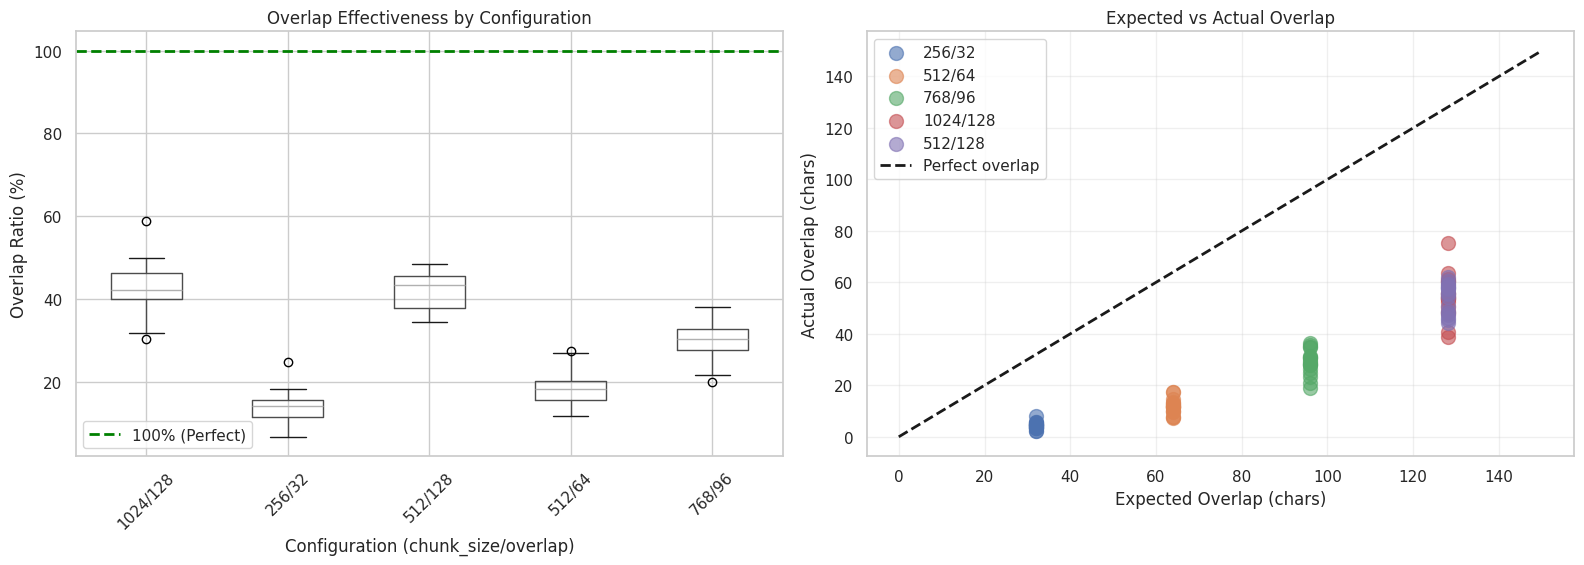

In [19]:
configs_with_overlap = df[df['chunk_overlap'] > 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Box plot: Overlap ratio by configuration
configs_with_overlap.boxplot(column='overlap_ratio', by='config', ax=ax1)
ax1.axhline(100, color='green', linestyle='--', linewidth=2, label='100% (Perfect)')
ax1.set_xlabel('Configuration (chunk_size/overlap)')
ax1.set_ylabel('Overlap Ratio (%)')
ax1.set_title('Overlap Effectiveness by Configuration')
ax1.get_figure().suptitle('')
ax1.legend()
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# Scatter: Expected vs actual overlap
for config in configs_with_overlap['config'].unique():
    subset = configs_with_overlap[configs_with_overlap['config'] == config]
    ax2.scatter(subset['chunk_overlap'], subset['avg_overlap'], label=config, alpha=0.6, s=100)

ax2.plot([0, 150], [0, 150], 'k--', linewidth=2, label='Perfect overlap')
ax2.set_xlabel('Expected Overlap (chars)')
ax2.set_ylabel('Actual Overlap (chars)')
ax2.set_title('Expected vs Actual Overlap')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Visualization 3: Boundary Quality

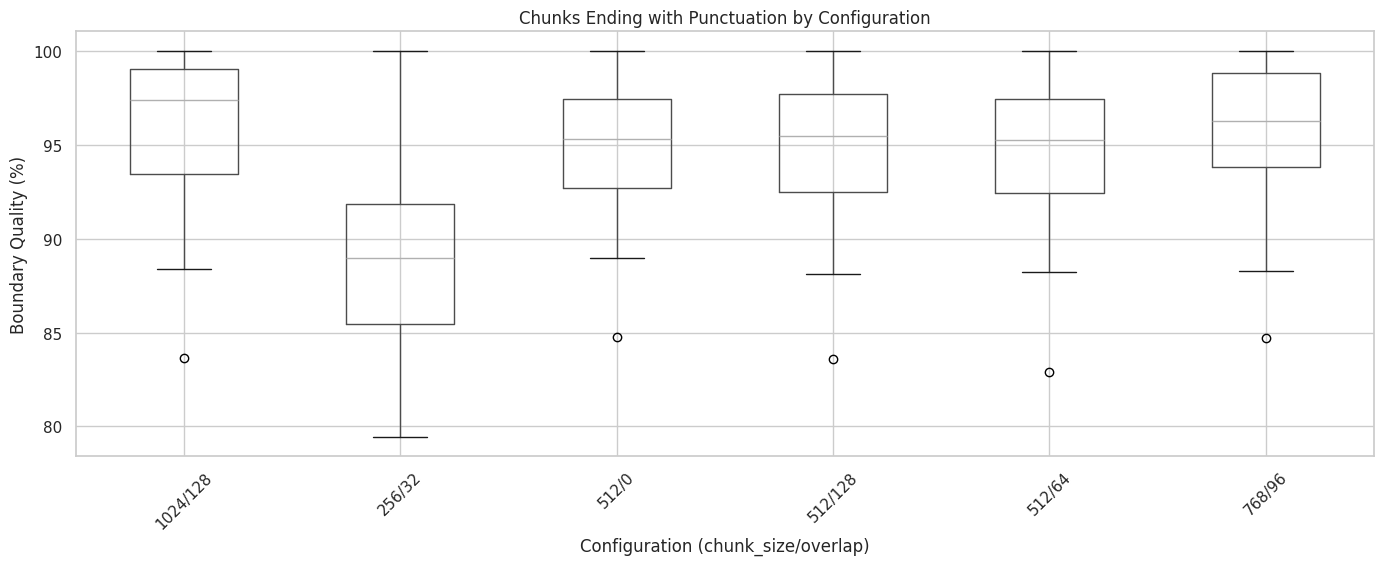

In [20]:
fig, ax = plt.subplots(figsize=(14, 6))

df.boxplot(column='boundary_quality', by='config', ax=ax)
ax.set_xlabel('Configuration (chunk_size/overlap)')
ax.set_ylabel('Boundary Quality (%)')
ax.set_title('Chunks Ending with Punctuation by Configuration')
ax.get_figure().suptitle('')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

## Visualization 4: Document Type Comparison

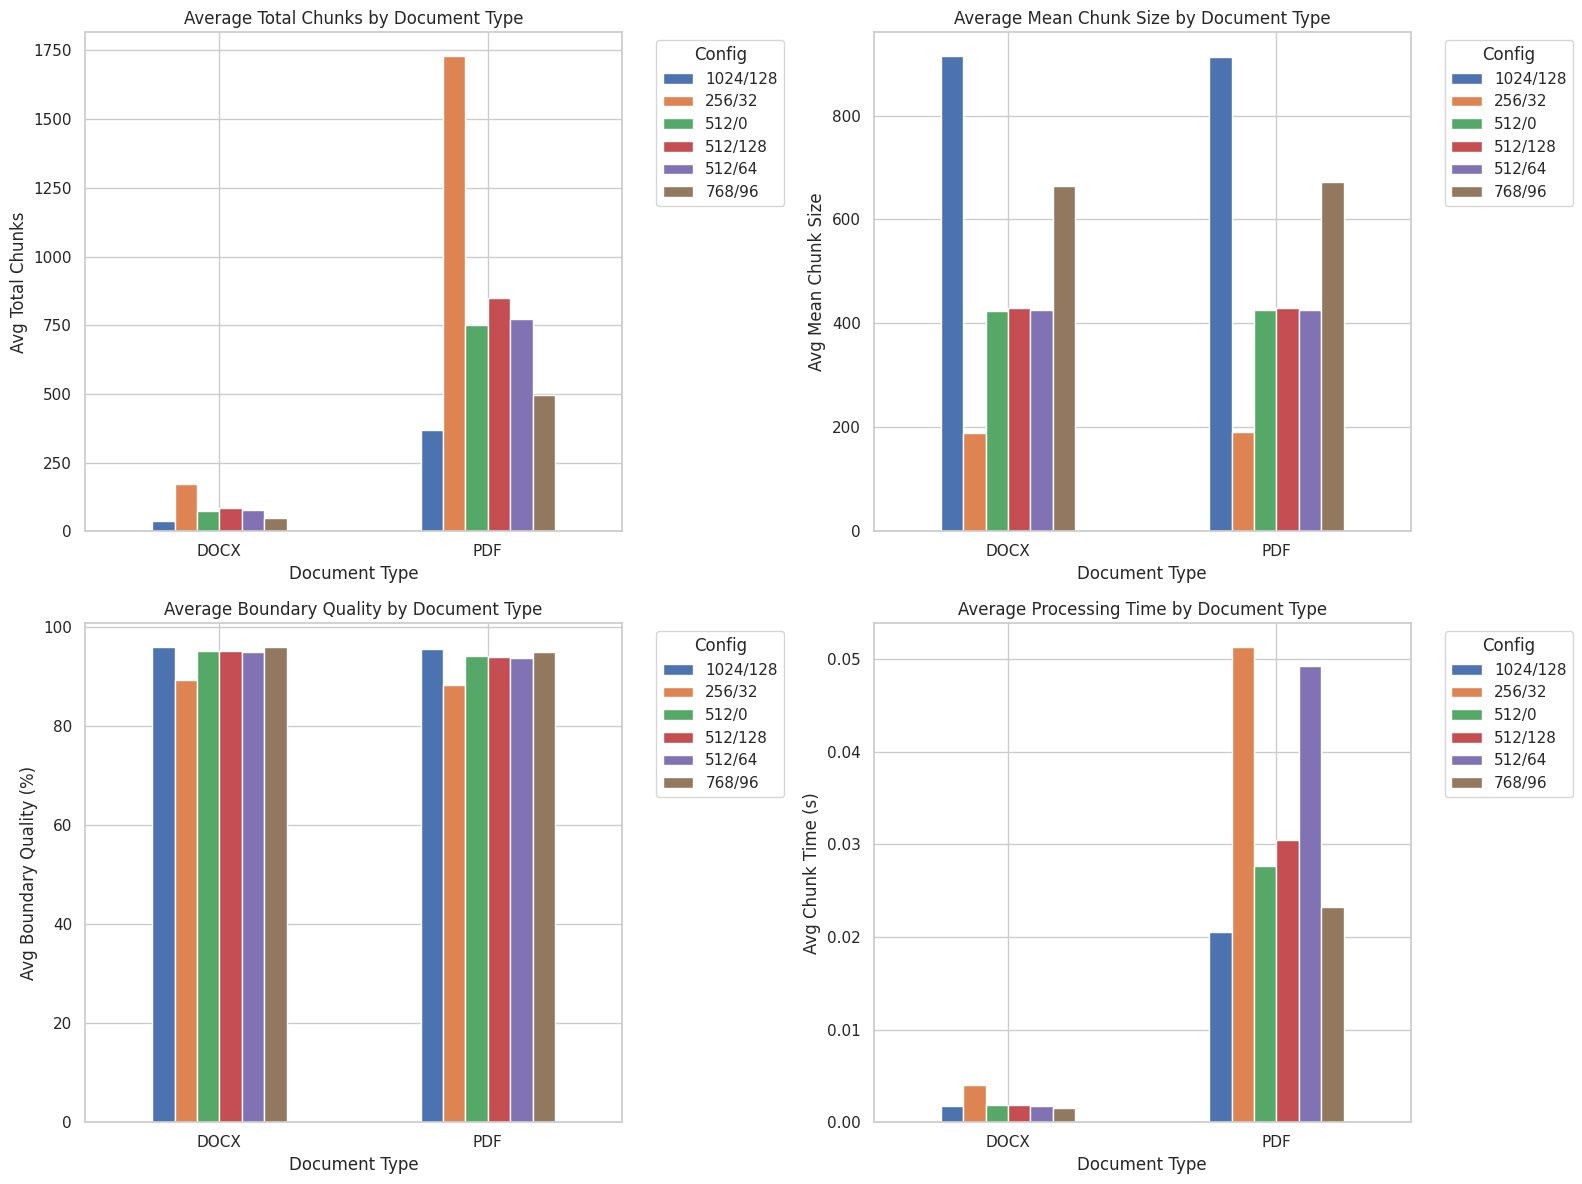

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Total chunks by doc type and config
df.groupby(['doc_type', 'config'])['total_chunks'].mean().unstack().plot(kind='bar', ax=axes[0, 0])
axes[0, 0].set_xlabel('Document Type')
axes[0, 0].set_ylabel('Avg Total Chunks')
axes[0, 0].set_title('Average Total Chunks by Document Type')
axes[0, 0].legend(title='Config', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0, 0].tick_params(axis='x', rotation=0)

# Mean chunk size by doc type and config
df.groupby(['doc_type', 'config'])['mean_size'].mean().unstack().plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_xlabel('Document Type')
axes[0, 1].set_ylabel('Avg Mean Chunk Size')
axes[0, 1].set_title('Average Mean Chunk Size by Document Type')
axes[0, 1].legend(title='Config', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0, 1].tick_params(axis='x', rotation=0)

# Boundary quality by doc type and config
df.groupby(['doc_type', 'config'])['boundary_quality'].mean().unstack().plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_xlabel('Document Type')
axes[1, 0].set_ylabel('Avg Boundary Quality (%)')
axes[1, 0].set_title('Average Boundary Quality by Document Type')
axes[1, 0].legend(title='Config', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 0].tick_params(axis='x', rotation=0)

# Processing time by doc type and config
df.groupby(['doc_type', 'config'])['chunk_time'].mean().unstack().plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_xlabel('Document Type')
axes[1, 1].set_ylabel('Avg Chunk Time (s)')
axes[1, 1].set_title('Average Processing Time by Document Type')
axes[1, 1].legend(title='Config', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Visualization 5: Performance Heatmap

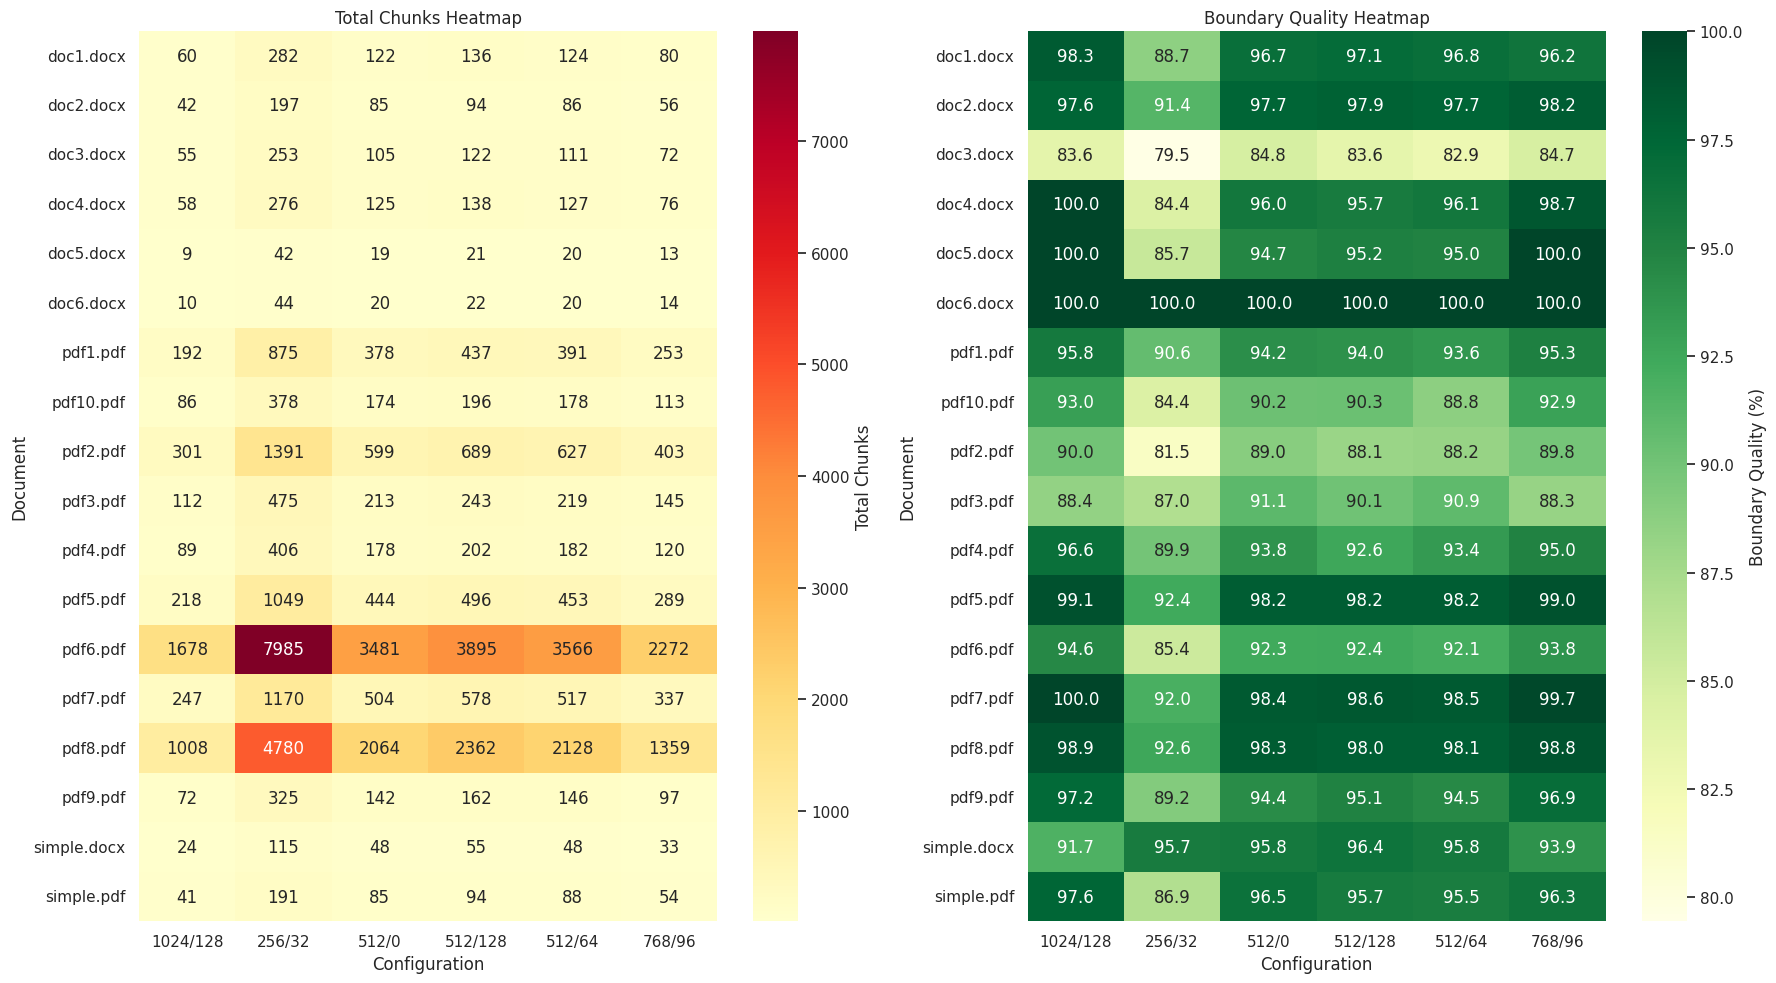

In [22]:
# Create pivot table for heatmap
pivot_chunks = df.pivot_table(values='total_chunks', index='document', columns='config', aggfunc='mean')
pivot_boundary = df.pivot_table(values='boundary_quality', index='document', columns='config', aggfunc='mean')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))

# Heatmap: Total chunks
sns.heatmap(pivot_chunks, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax1, cbar_kws={'label': 'Total Chunks'})
ax1.set_xlabel('Configuration')
ax1.set_ylabel('Document')
ax1.set_title('Total Chunks Heatmap')

# Heatmap: Boundary quality
sns.heatmap(pivot_boundary, annot=True, fmt='.1f', cmap='YlGn', ax=ax2, cbar_kws={'label': 'Boundary Quality (%)'})
ax2.set_xlabel('Configuration')
ax2.set_ylabel('Document')
ax2.set_title('Boundary Quality Heatmap')

plt.tight_layout()
plt.show()

## Best Configuration Analysis

**Important:** We use `chars_per_chunk` instead of absolute chunk count to make the metric independent of document size.

In [23]:
# Calculate composite score (weighted average of normalized metrics)
df_normalized = df.copy()

# Calculate chars per chunk (document-size independent efficiency metric)
df_normalized['chars_per_chunk'] = df_normalized['doc_size'] / df_normalized['total_chunks']

# Normalize metrics (0-1 scale)
df_normalized['norm_overlap'] = df_normalized['overlap_ratio'] / 100
df_normalized['norm_boundary'] = df_normalized['boundary_quality'] / 100

# Normalize chars_per_chunk (higher is better - more content per chunk)
min_cpp = df_normalized['chars_per_chunk'].min()
max_cpp = df_normalized['chars_per_chunk'].max()
df_normalized['norm_efficiency'] = (df_normalized['chars_per_chunk'] - min_cpp) / (max_cpp - min_cpp)

# Composite score (adjust weights as needed)
# 40% efficiency (chars per chunk), 30% overlap, 30% boundary quality
df_normalized['composite_score'] = (
    0.3 * df_normalized['norm_overlap'] +
    0.3 * df_normalized['norm_boundary'] +
    0.4 * df_normalized['norm_efficiency']
)

# Aggregate by configuration
config_scores = df_normalized.groupby('config').agg({
    'composite_score': 'mean',
    'total_chunks': 'mean',
    'chars_per_chunk': 'mean',
    'overlap_ratio': 'mean',
    'boundary_quality': 'mean',
}).round(3)

config_scores = config_scores.sort_values('composite_score', ascending=False)

print("Configuration Ranking (by composite score):")
print("="*80)
print("Metric explanation:")
print("  - Composite Score: Weighted average (40% efficiency, 30% overlap, 30% boundary)")
print("  - Chars/Chunk: Average characters per chunk (document-size independent)")
print("  - Overlap Ratio: Actual overlap / Expected overlap (%)")
print("  - Boundary Quality: % of chunks ending with punctuation")
print("="*80)
display(config_scores)

print("\n" + "="*80)
print(f"BEST CONFIGURATION: {config_scores.index[0]}")
print("="*80)
print(f"  - Composite Score: {config_scores.iloc[0]['composite_score']:.3f}")
print(f"  - Avg Chars/Chunk: {config_scores.iloc[0]['chars_per_chunk']:.1f}")
print(f"  - Avg Total Chunks: {config_scores.iloc[0]['total_chunks']:.1f}")
print(f"  - Avg Overlap Ratio: {config_scores.iloc[0]['overlap_ratio']:.2f}%")
print(f"  - Avg Boundary Quality: {config_scores.iloc[0]['boundary_quality']:.2f}%")

Configuration Ranking (by composite score):
Metric explanation:
  - Composite Score: Weighted average (40% efficiency, 30% overlap, 30% boundary)
  - Chars/Chunk: Average characters per chunk (document-size independent)
  - Overlap Ratio: Actual overlap / Expected overlap (%)
  - Boundary Quality: % of chunks ending with punctuation


,composite_score,total_chunks,chars_per_chunk,overlap_ratio,boundary_quality
config,,,,,
1024/128,0.799,239.000,860.706,42.574,95.695
768/96,0.637,321.444,641.086,30.144,95.418
512/128,0.521,552.333,377.628,42.040,94.391
512/64,0.471,501.722,415.432,18.408,94.217
512/0,0.423,488.111,426.284,0.000,94.556
256/32,0.311,1124.111,186.272,13.877,88.723



BEST CONFIGURATION: 1024/128
  - Composite Score: 0.799
  - Avg Chars/Chunk: 860.7
  - Avg Total Chunks: 239.0
  - Avg Overlap Ratio: 42.57%
  - Avg Boundary Quality: 95.69%


## Export Results

In [25]:
# Export detailed results to CSV
output_path = Path("../data/results/chunking_evaluation_results.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_path, index=False)
print(f"Results exported to: {output_path}")

# Export aggregate statistics
agg_output_path = Path("../data/results/chunking_evaluation_aggregate.csv")
agg_stats.to_csv(agg_output_path)
print(f"Aggregate stats exported to: {agg_output_path}")

# Export configuration ranking
ranking_output_path = Path("../data/results/chunking_configuration_ranking.csv")
config_scores.to_csv(ranking_output_path)
print(f"Configuration ranking exported to: {ranking_output_path}")

Results exported to: ../data/results/chunking_evaluation_results.csv
Aggregate stats exported to: ../data/results/chunking_evaluation_aggregate.csv
Configuration ranking exported to: ../data/results/chunking_configuration_ranking.csv
